In [1]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt                                                           #Draws all the charts and graphs
import matplotlib.dates as mdates
import numpy as np                                                                        #Does fast math on lists of numbers
from scipy.stats import skew, kurtosis, jarque_bera, levene, ttest_ind, mannwhitneyu

plt.style.use('dark_background')                                                          #Set the style before creating any figure
pd.set_option('display.width', 200)

v_assets = ['AAPL', 'TSLA', 'AMZN']
benchmark = 'SPY'                                                                         #S&P 500 ETF: separates market-wide moves from stock-specific ones
tickers = v_assets + [benchmark]
periods = {                                                                               #End date is exclusive
    'Before COVID': ('2016-01-01', '2020-03-12'),
    'COVID shock':  ('2020-03-12', '2022-01-01'),
    'After COVID':  ('2022-01-01', '2026-01-01')
}
period_colors = {'Before COVID': 'tab:cyan', 'COVID shock': 'tab:red', 'After COVID': 'tab:olive'}

#Prices are cached in a CSV so the results don't change when Yahoo revises its data
DATA_FILE = 'data/prices.csv'
if os.path.exists(DATA_FILE):
    data = pd.read_csv(DATA_FILE, index_col = 0, parse_dates = True)
else:
    data = yf.download(tickers, start = '2016-01-01', end = '2026-01-01',
                       auto_adjust = True, progress = False)['Close'][tickers]
    irx = yf.download('^IRX', start = '2016-01-01', end = '2026-01-01',
                      auto_adjust = True, progress = False)['Close']['^IRX']              #13-week T-bill yield, % per year
    data['RF'] = irx.reindex(data.index).ffill().bfill() / 100 / 252                      #Daily risk-free rate
    os.makedirs('data', exist_ok = True)
    data.to_csv(DATA_FILE)

close = data[tickers]
rf = data['RF']
log_ret = np.log(close / close.shift(1)).dropna()                                         #Daily log returns, rows = days, cols = assets
excess_ret = log_ret.sub(rf.loc[log_ret.index], axis = 0)                                 #Return above the risk-free rate

def in_period(df, period):
    start, end = periods[period]
    return df[(df.index >= start) & (df.index < end)]

def shade_periods(ax):                                                                    #Colors the background by period
    for period, (start, end) in periods.items():
        ax.axvspan(np.datetime64(start), np.datetime64(end), color = period_colors[period], alpha = 0.08)

def year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

print(f'{len(close)} trading days, {close.index[0].date()} to {close.index[-1].date()}')

2514 trading days, 2016-01-04 to 2025-12-31


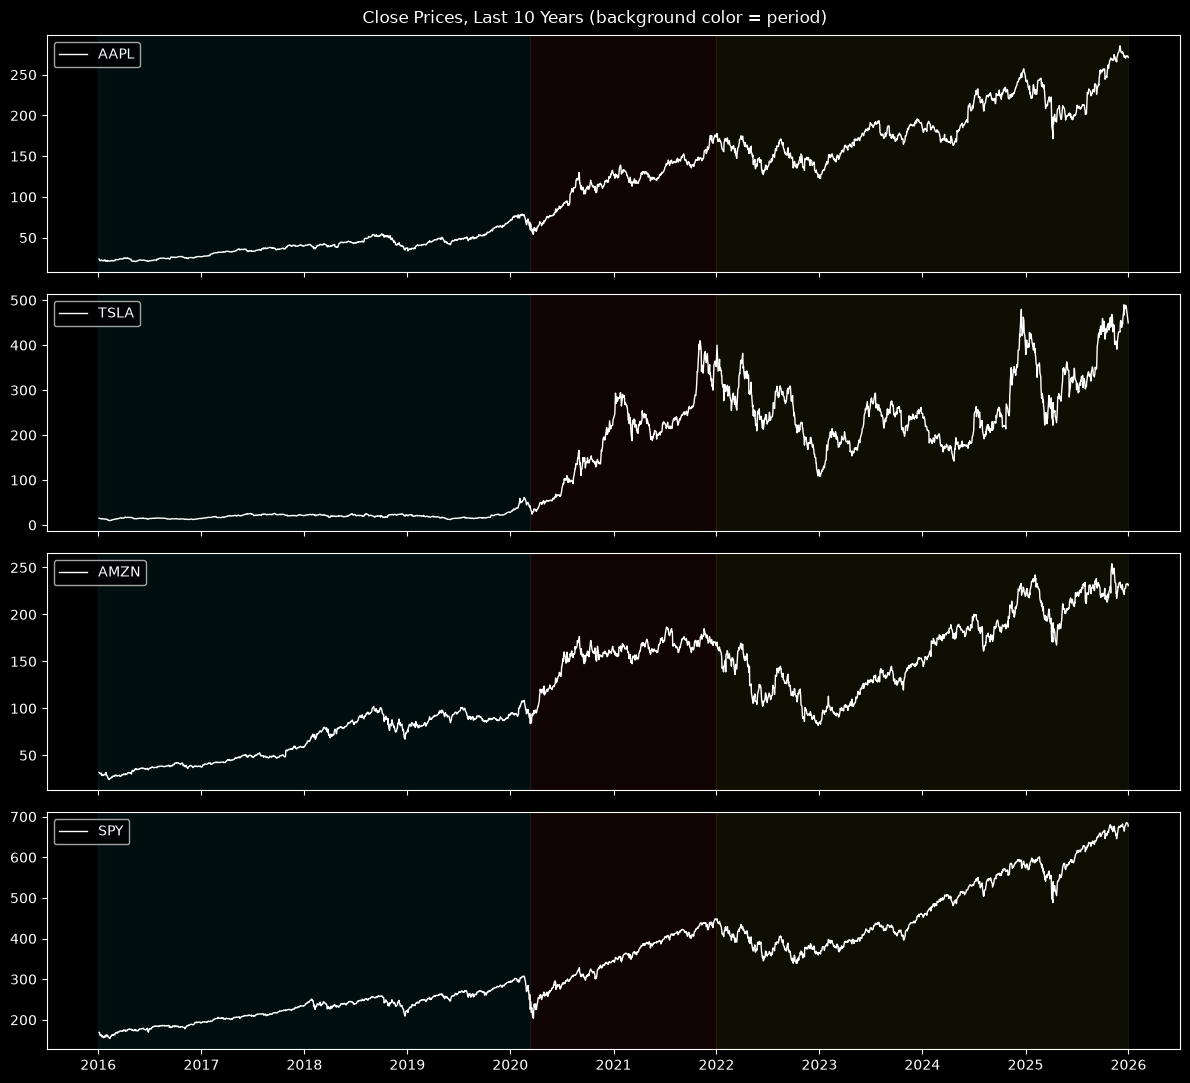

In [2]:
fig, axes = plt.subplots(len(tickers), 1, figsize = (12, 11), sharex = True)
fig.suptitle('Close Prices, Last 10 Years (background color = period)')
for ax, ticker in zip(axes, tickers):
    ax.plot(close[ticker], label = ticker, color = 'white', linewidth = 1)
    shade_periods(ax)
    ax.legend(loc = 2)
year_axis(axes[-1])
plt.tight_layout()                                                                        #Automatically adjusts spacing between subplots
plt.show()

In [3]:
def max_drawdown(prices):                                                                 #Worst fall from a previous peak
    return (prices / prices.cummax() - 1).min()

rows = []
for period in periods:
    r = in_period(log_ret, period)
    ex = in_period(excess_ret, period)
    p = in_period(close, period)
    for ticker in tickers:
        rows.append({
            'Ticker':       ticker,
            'Period':       period,
            'Return %':     100 * r[ticker].mean() * 252,                                 #Average yearly profit in percent
            'Volatility %': 100 * r[ticker].std() * np.sqrt(252),                         #Risk (how much the stock price jumps around)
            'Sharpe':       ex[ticker].mean() * 252 / (ex[ticker].std() * np.sqrt(252)),  #Return per unit of risk
            'Beta':         r[ticker].cov(r[benchmark]) / r[benchmark].var(),             #How strongly it follows the market
            'Max DD %':     100 * max_drawdown(p[ticker]),
            'Skew':         skew(r[ticker]),                                              #Big losses or big gains are more extreme
            'Kurt':         kurtosis(r[ticker], fisher = False),                          #How often extreme days happen (normal = 3)
            'JB p':         jarque_bera(r[ticker]).pvalue                                 #p < 0.05 -> returns are NOT normally distributed
        })

stats = pd.DataFrame(rows).set_index(['Ticker', 'Period'])
print('Average risk-free rate (% per year):')
print((100 * 252 * pd.Series({period: in_period(rf, period).mean() for period in periods})).round(2).to_string(), '\n')
print(stats.round({'Return %': 1, 'Volatility %': 1, 'Sharpe': 2, 'Beta': 2, 'Max DD %': 1,
                   'Skew': 2, 'Kurt': 1, 'JB p': 4}).to_string())

Average risk-free rate (% per year):
Before COVID    1.30
COVID shock     0.06
After COVID     4.01 

                     Return %  Volatility %  Sharpe  Beta  Max DD %  Skew  Kurt  JB p
Ticker Period                                                                        
AAPL   Before COVID      24.7          25.9    0.90  1.27     -38.5 -0.38   8.4   0.0
TSLA   Before COVID      25.0          50.1    0.47  1.34     -53.5 -0.06   9.2   0.0
AMZN   Before COVID      25.1          28.3    0.84  1.22     -34.1  0.17   8.9   0.0
SPY    Before COVID       9.3          14.7    0.55  1.00     -19.3 -1.15  13.8   0.0
AAPL   COVID shock       52.9          36.2    1.46  1.16     -20.4 -0.33   9.4   0.0
TSLA   COVID shock      116.9          70.7    1.65  1.37     -36.2 -0.29   7.1   0.0
AMZN   COVID shock       33.4          31.6    1.05  0.74     -16.4 -0.09   5.4   0.0
SPY    COVID shock       32.0          24.2    1.32  1.00     -16.7 -1.04  19.3   0.0
AAPL   After COVID       11.2         

In [4]:
print('Correlation of daily returns (1 = move exactly together)')
for period in periods:
    print(f'\n{period}')
    print(in_period(log_ret, period).corr().round(2).to_string())

Correlation of daily returns (1 = move exactly together)

Before COVID
      AAPL  TSLA  AMZN   SPY
AAPL  1.00  0.33  0.55  0.72
TSLA  0.33  1.00  0.33  0.39
AMZN  0.55  0.33  1.00  0.63
SPY   0.72  0.39  0.63  1.00

COVID shock
      AAPL  TSLA  AMZN   SPY
AAPL  1.00  0.48  0.68  0.78
TSLA  0.48  1.00  0.42  0.47
AMZN  0.68  0.42  1.00  0.57
SPY   0.78  0.47  0.57  1.00

After COVID
      AAPL  TSLA  AMZN   SPY
AAPL  1.00  0.51  0.56  0.77
TSLA  0.51  1.00  0.47  0.59
AMZN  0.56  0.47  1.00  0.74
SPY   0.77  0.59  0.74  1.00


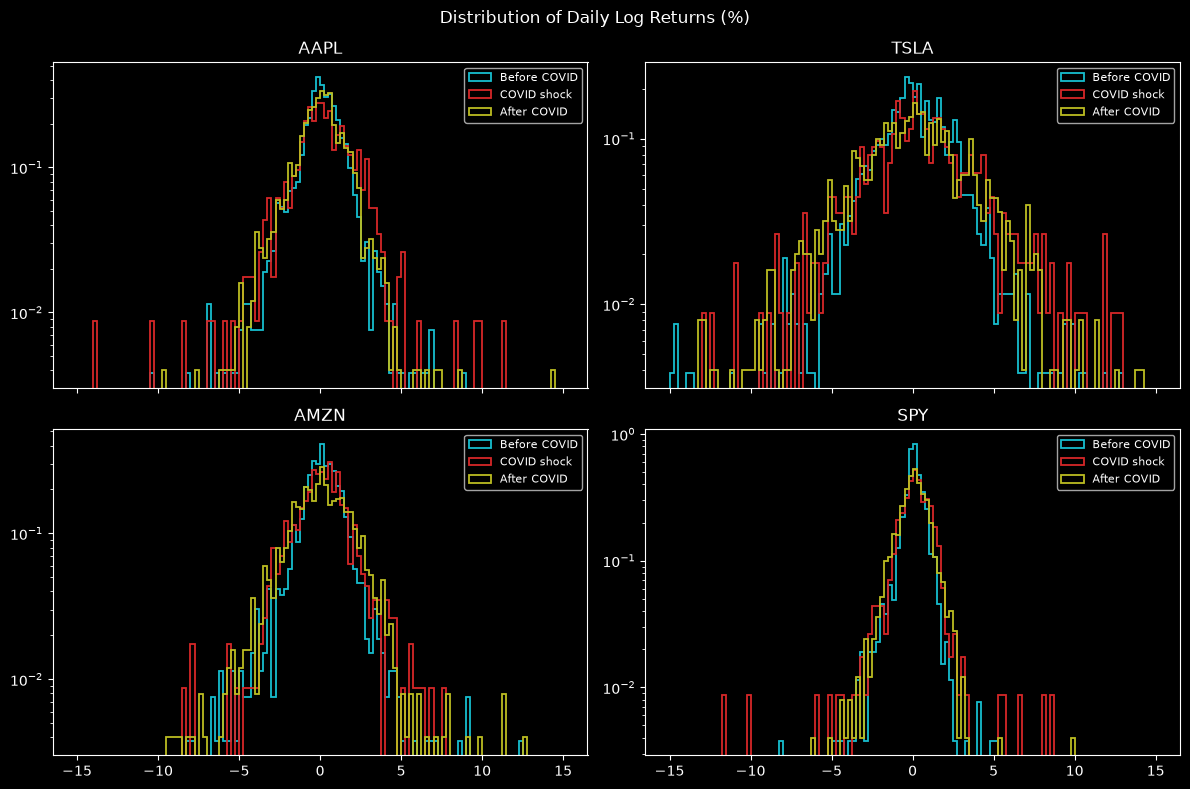

In [5]:
#Return distributions: periods overlaid on the same axis so they can be compared directly
bins = np.linspace(-15, 15, 121)
fig, axes = plt.subplots(2, 2, figsize = (12, 8), sharex = True)
fig.suptitle('Distribution of Daily Log Returns (%)')
for ax, ticker in zip(axes.flat, tickers):
    for period in periods:
        ax.hist(100 * in_period(log_ret, period)[ticker], bins = bins, density = True,
                histtype = 'step', linewidth = 1.3, color = period_colors[period], label = period)
    ax.set_title(ticker)
    ax.set_yscale('log')                                                                  #Log scale makes the fat tails visible
    ax.legend(loc = 1, fontsize = 8)
plt.tight_layout()
plt.show()